# Adding tracing to offline bagel

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/Rtmp9wxtp6/remotes773552d942b53/grosed-bagel-46e2926/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.8.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.8.0’

## Using bagelR - 1 : Detecting Change in Mean

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Example 1 - change in mean

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 1 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:

prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transform function

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

#### Set model parameters 

In [7]:
p <- 1.0;
p0 <- 0.9;
noise_nu <- 1.0;
noise_iota <- 1.0
max_particles <- 200
threshold <- 0.8

#### Generate some data - change at t = 501 

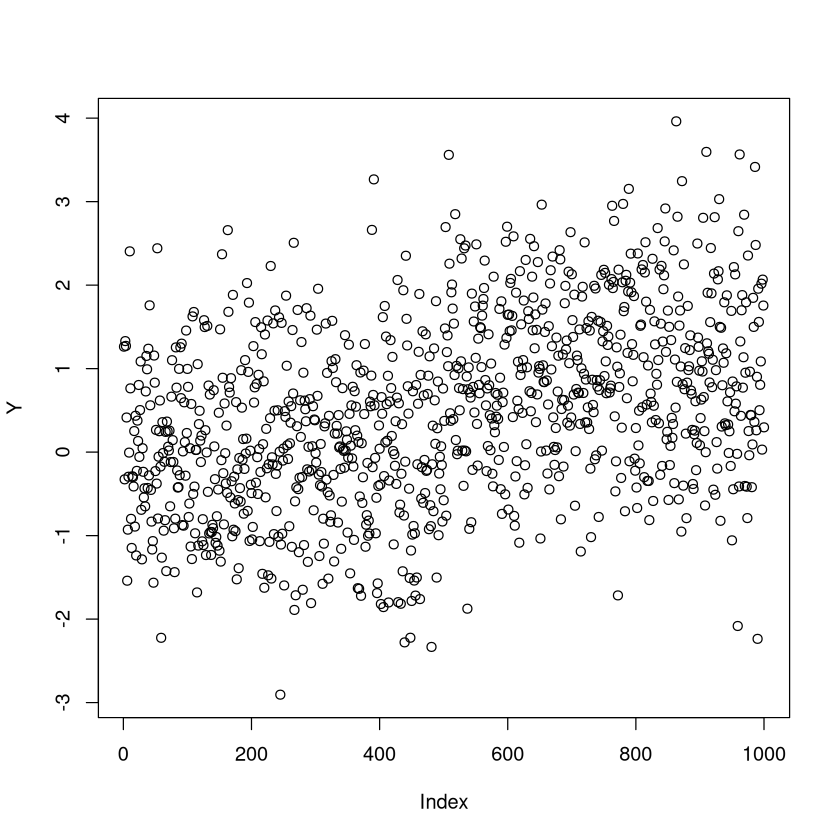

In [8]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Offline analysis - unknown variance

Note - the default tracer does not trace anything

In [9]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,noise_nu,noise_iota,max_particles,threshold)

#### Check for a changepoint

In [10]:
changepoint(results)

$location
[1] 501

$detected
[1] 513

#### Visualise weight at tau = 0

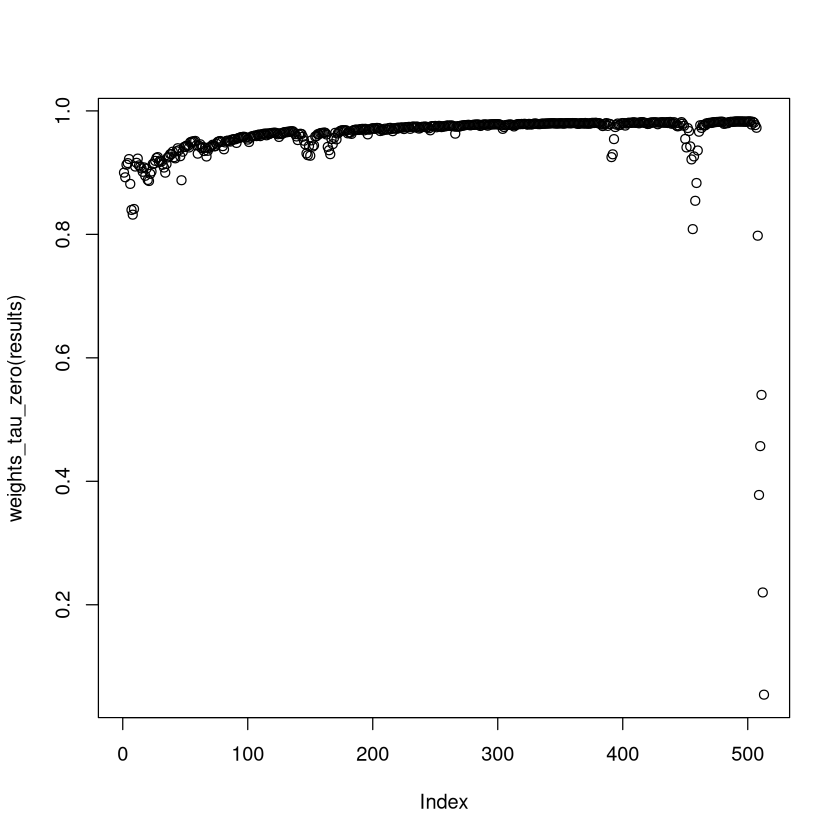

In [11]:
plot(weights_tau_zero(results))

#### Check the trace - it should be empty (the default behaviour)

In [12]:
print(results@trace)

list()


#### Define a tracer that collects everything about every particle in the case of unknown variance

In [13]:
everything_uv <- function(trace,bagel_object)
    {
        # get all attribibutes from the particle (note - unknown variance so include nu or iota)
        particle_attributes <- list("time" = time(bagel_object),
                               "taus" = taus(bagel_object),
                               "weights" = weights(bagel_object),
                               "mus" = mus(bagel_object),
                               "sigmas" = sigmas(bagel_object),
                               "nu" = nu(bagel_object),
                               "iota" = iota(bagel_object))     
        # append them to the trace (note - do not silently collapse the list)
        trace <- append(trace,list(particle_attributes))
    return(trace)
}

#### Repeat analysis - but use everything_uv tracer

In [14]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,noise_nu,noise_iota,max_particles,threshold,tracer=everything_uv)

#### Look at the trace for first few particles

In [15]:
head(results@trace)

[[1]]
[[1]]$time
[1] 1

[[1]]$taus
[1] 0

[[1]]$weights
[1] 0.9

[[1]]$mus
[[1]]$mus[[1]]
         [,1]
[1,] 1.219129


[[1]]$sigmas
[[1]]$sigmas[[1]]
          [,1]
[1,] 0.8333333


[[1]]$nu
[1] 1.5

[[1]]$iota
[1] 1.005762


[[2]]
[[2]]$time
[1] 2

[[2]]$taus
[1] 0 1

[[2]]$weights
[1] 0.8924682 0.1075318

[[2]]$mus
[[2]]$mus[[1]]
          [,1]
[1,] 0.5166913

[[2]]$mus[[2]]
           [,1]
[1,]  0.7646104
[2,] -0.5454219


[[2]]$sigmas
[[2]]$sigmas[[1]]
          [,1]
[1,] 0.4545455

[[2]]$sigmas[[2]]
           [,1]       [,2]
[1,]  0.5882353 -0.2941176
[2,] -0.2941176  0.6470588


[[2]]$nu
[1] 2

[[2]]$iota
[1] 1.657074


[[3]]
[[3]]$time
[1] 3

[[3]]$taus
[1] 0 1 2

[[3]]$weights
[1] 0.91283326 0.04288730 0.04427944

[[3]]$mus
[[3]]$mus[[1]]
          [,1]
[1,] 0.7707876

[[3]]$mus[[2]]
           [,1]
[1,]  0.9629337
[2,] -0.3074338

[[3]]$mus[[3]]
          [,1]
[1,] 0.6672669
[2,] 0.3312662


[[3]]$sigmas
[[3]]$sigmas[[1]]
       [,1]
[1,] 0.3125

[[3]]$sigmas[[2]]
           [,1]       [,2]
[1,]  0.5357143 -0.3571429
[2,] -0.3571429  0.5714286

[[3]]$sigmas[[3]]
           [,1]       [,2]
[1,]  0.3703704 -0.1851852
[2,] -0.1851852  0.5925926


[[3]]$nu
[1] 2.5

[[3]]$iota
[1] 1.884342


[[4]]
[[4]]$time
[1] 4

[[4]]$taus
[1] 0 1 2 3

[[4]]$weights
[1] 0.91549269 0.02653133 0.03075744 0.02721854

[[4]]$mus
[[4]]$mus[[1]]
          [,1]
[1,] 0.8902261

[[4]]$mus[[2]]
           [,1]
[1,]  1.0420272
[2,] -0.2125216

[[4]]$mus[[3]]
          [,1]
[1,] 0.6991153
[2,] 0.4013327

[[4]]$mus[[4]]
          [,1]
[1,] 0.8385770
[2,] 0.2169262


[[4]]$sigmas
[[4]]$sigmas[[1]]
          [,1]
[1,] 0.2380952

[[4]]$sigmas[[2]]
           [,1]       [,2]
[1,]  0.5128205 -0.3846154
[2,] -0.3846154  0.5384615

[[4]]$sigmas[[3]]
           [,1]       [,2]
[1,]  0.3488372 -0.2325581
[2,] -0.2325581  0.4883721

[[4]]$sigmas[[4]]
           [,1]       [,2]
[1,]  0.2702703 -0.1351351
[2,] -0.1351351  0.5675676


[[4]]$nu
[1] 3

[[4]]$iota
[1] 1.980207


[[5]]
[[5]]$time
[1] 5

[[5]]$taus
[1] 0 1 2 3 4

[[5]]$weights
[1] 0.92200526 0.02069040 0.01968182 0.01719977 0.02042276

[[5]]$mus
[[5]]$mus[[1]]
          [,1]
[1,] 0.7987675

[[5]]$mus[[2]]
           [,1]
[1,]  1.0005408
[2,] -0.2623053

[[5]]$mus[[3]]
          [,1]
[1,] 0.6409961
[2,] 0.2734704

[[5]]$mus[[4]]
           [,1]
[1,] 0.78333029
[2,] 0.04013673

[[5]]$mus[[5]]
           [,1]
[1,]  0.8396320
[2,] -0.2124953


[[5]]$sigmas
[[5]]$sigmas[[1]]
          [,1]
[1,] 0.1923077

[[5]]$sigmas[[2]]
     [,1]  [,2]
[1,]  0.5 -0.40
[2,] -0.4  0.52

[[5]]$sigmas[[3]]
           [,1]       [,2]
[1,]  0.3389831 -0.2542373
[2,] -0.2542373  0.4406780

[[5]]$sigmas[[4]]
           [,1]       [,2]
[1,]  0.2586207 -0.1724138
[2,] -0.1724138  0.4482759

[[5]]$sigmas[[5]]
          [,1]       [,2]
[1,]  0.212766 -0.1063830
[2,] -0.106383  0.5531915


[[5]]$nu
[1] 3.5

[[5]]$iota
[1] 2.071549


[[6]]
[[6]]$time
[1] 6

[[6]]$taus
[1] 0 1 2 3 4 5

[[6]]$weights
[1] 0.88176022 0.01739172 0.01270266 0.01546549 0.02943959 0.04324032

[[6]]$mus
[[6]]$mus[[1]]
         [,1]
[1,] 0.421555

[[6]]$mus[[2]]
           [,1]
[1,]  0.8138043
[2,] -0.4863891

[[6]]$mus[[3]]
            [,1]
[1,]  0.47736831
[2,] -0.08651065

[[6]]$mus[[4]]
           [,1]
[1,]  0.6337469
[2,] -0.4385300

[[6]]$mus[[5]]
           [,1]
[1,]  0.6912014
[2,] -0.8359038

[[6]]$mus[[6]]
           [,1]
[1,]  0.5936168
[2,] -1.0667834


[[6]]$sigmas
[[6]]$sigmas[[1]]
          [,1]
[1,] 0.1612903

[[6]]$sigmas[[2]]
           [,1]       [,2]
[1,]  0.4918033 -0.4098361
[2,] -0.4098361  0.5081967

[[6]]$sigmas[[3]]
           [,1]       [,2]
[1,]  0.3333333 -0.2666667
[2,] -0.2666667  0.4133333

[[6]]$sigmas[[4]]
           [,1]       [,2]
[1,]  0.2531646 -0.1898734
[2,] -0.1898734  0.3924051

[[6]]$sigmas[[5]]
           [,1]       [,2]
[1,]  0.2054795 -0.1369863
[2,] -0.1369863  0.4246575

[[6]]$sigmas[[6]]
           [,1]       [,2]
[1,]  0.1754386 -0.0877193
[2,] -0.0877193  0.5438596


[[6]]$nu
[1] 4

[[6]]$iota
[1] 4.365252

#### Use the trace to look at a particular attribute (tau) at a particular epoch (300) for all active particles 

In [16]:
results@trace[[300]]$taus

[1]   0   1   2   3   4   5   6   9  10  11  12  14  17  19  21  23  25  26
 [19]  27  28  31  33  34  35  38  40  43  44  45  46  47  48  51  52  56  58
 [37]  59  62  64  66  67  72  74  75  78  79  80  81  84  86  88  90  91  93
 [55]  97  99 100 101 104 106 107 109 111 114 115 116 118 122 123 124 125 126
 [73] 128 130 132 133 134 135 136 137 138 139 143 144 145 146 149 150 151 153
 [91] 154 156 161 162 163 164 165 169 170 171 173 174 175 176 178 179 181 182
[109] 183 187 189 192 193 194 195 196 198 199 200 201 202 203 204 205 207 209
[127] 210 212 214 215 216 218 219 220 221 224 225 227 229 230 233 234 235 236
[145] 238 240 241 242 244 245 246 247 248 250 251 252 253 254 257 258 260 261
[163] 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279
[181] 280 281 282 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297
[199] 298 299

#### Use the trace to look at a particular attribute (sigma) at a particular epoch (300) for the nth (10th) active particle 

In [17]:
results@trace[[300]]$sigmas[[10]]

0.08199039,-0.08170766
-0.08170766,0.08487419


#### Define a tracer that only keeps only the attributes of the particle with least weight for the case of uknown variance

In [18]:
min_weight_uv <- function(trace,bagel_object)
{
    min_active_weight_index <- which.min(as.numeric(active_weights(bagel_object)))
    particle_attributes <- list("time" = time(bagel_object),
                               "tau" = taus(bagel_object)[[min_active_weight_index]],
                               "weight" = weights(bagel_object)[[min_active_weight_index]],
                               "mu" = mus(bagel_object)[[min_active_weight_index]],
                               "sigma" = sigmas(bagel_object)[[min_active_weight_index]],
                               "nu" = nu(bagel_object),
                               "iota" = iota(bagel_object))
   trace <- append(trace,list(particle_attributes))
   return(trace)
}

#### Repeat analysis - but use min_weight_uv tracer

In [19]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,noise_nu,noise_iota,max_particles,threshold,tracer=min_weight_uv)

#### Use the trace to look at a particular attribute (sigma) at a particular epoch (300) for active particle with the least weight 

In [20]:
results@trace[[307]]$sigma

0.007288939,-0.007246561
-0.007246561,0.013018383
